### Build a Basic ChatBot with LangGraph(Graph API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [3]:
import os
from pathlib import Path
from langchain_groq import ChatGroq

# 1. Read the line we just confirmed is there
env_file_path = Path.cwd().parent / ".env"
with open(env_file_path, "r", encoding="utf-8") as f:
    line = f.read().splitlines()[0]

# 2. Extract the key directly from the text split
secret_key = line.split("=", 1)[1].strip()

# 3. Explicitly inject it into os.environ for LangGraph nodes to see
os.environ["GROQ_API_KEY"] = secret_key

# 4. Pass it directly to ChatGroq to guarantee it binds right now
llm = ChatGroq(
    model="llama3-8b-8192",
    groq_api_key=secret_key
)

print("✅ Model successfully initialized with the updated key!")

✅ Model successfully initialized with the updated key!


In [4]:

from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama3-8b-8192")

In [5]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Llama 3 8B', 'status': 'deprecated', 'release_date': '2024-04-18', 'last_updated': '2024-04-18', 'open_weights': True, 'max_input_tokens': 8192, 'max_output_tokens': 8192, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000023AAD299F90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000023AAD29A990>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:

## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:

graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

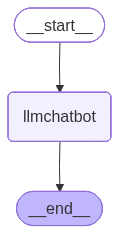

In [8]:

## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
import os
from langchain_groq import ChatGroq

# Re-initialize using a supported, active model
llm = ChatGroq(
    model="llama-3.1-8b-instant",  # Updated to a valid active model ID
    groq_api_key=os.environ["GROQ_API_KEY"]
)

print("✅ Model updated to an active version successfully!")

✅ Model updated to an active version successfully!


In [10]:
response = graph.invoke({"messages": "Hi"})
print(response)

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='cb18062c-6459-4a84-90da-7131060e215b'), AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.007025175, 'completion_tokens_details': None, 'prompt_time': 0.001664804, 'prompt_tokens_details': None, 'queue_time': 0.046303136, 'total_time': 0.008689979}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee9dd-898f-7d03-95be-91997454c75a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})]}


In [11]:

response["messages"][-1].content

'How can I assist you today?'

In [12]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm here to help answer any questions or provide information you need. How can I assist you today?


### Chatbot with Tool

In [13]:
import os
from pathlib import Path
from langchain_tavily import TavilySearch

# 1. Read your .env file cleanly
env_file_path = Path.cwd().parent / ".env"

tavily_key = None
with open(env_file_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip().startswith("TAVILY_API_KEY"):
            tavily_key = line.split("=", 1)[1].strip().strip("'\"")
            break

# 2. Inject it into os.environ and initialize the tool
if tavily_key:
    os.environ["TAVILY_API_KEY"] = tavily_key
    
    # Initialize the tool by passing the key explicitly
    tool = TavilySearch(max_results=2, tavily_api_key=tavily_key)
    print("🎉 Success! Tavily search tool initialized completely.")
    
    # 3. Test it out!
    print("\nTesting tool invocation:")
    print(tool.invoke("What is langgraph"))
else:
    print("❌ Could not find a line starting with 'TAVILY_API_KEY' in your .env file.")
    print("Please double check that you added it and saved the file.")

🎉 Success! Tavily search tool initialized completely.

Testing tool invocation:
{'query': 'What is langgraph', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph', 'title': 'What is LangGraph - GeeksforGeeks', 'content': "LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. LangChain uses a straightforward step-by-step pipeline where each task follows a fixed sequence from input to output while LangGraph allows flexible workflows with branching and parallel steps, making it better suited for complex, decision-based applications. ## Workflow of LangGraph. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. Here's a step by

In [14]:

## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [15]:
tools = [tool,multiply]

In [16]:
llm_with_tool=llm.bind_tools(tools)

In [17]:
llm_with_tool


_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000023AAD341090>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000023AAD342210>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin

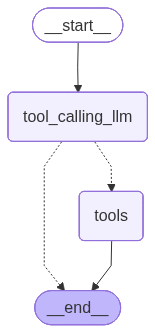

In [18]:

## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
response=graph.invoke({"messages":"What is the recent ai news"})


In [20]:
response['messages'][-1].content

'{"query": "Artificial Intelligence latest", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-bezos-predicts-labor-shortage", "title": "Fox News AI Newsletter: Bezos predicts labor shortage - Fox News", "score": 0.57723385, "published_date": "Fri, 19 Jun 2026 13:11:08 GMT", "content": "* #### Fox News AI Newsletter: Top 12 takeaways from Apple\'s new AI features. ## Stay up to date on the latest AI technology advancements and learn about the challenges and opportunities AI presents. By Fox News Staff  Fox News. ### **Welcome to Fox News’ Artificial Intelligence newsletter with the latest AI technology advancements.**. **POWER STRUGGLE:** As data center projects continue to get shut down across the country, \\"Shark Tank\\" star Kevin O\'Leary and other investors are warning that the facilities are needed to compete with China in the artificial intelligence race. **TABLES TURNED:** As artificial intelligence (AI) 

In [21]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (faezhwb49)
 Call ID: faezhwb49
  Args:
    query: Recent AI news
    search_depth: advanced
    time_range: month
    topic: news
  tavily_search (mr7m55h8p)
 Call ID: mr7m55h8p
  Args:
    query: Artificial Intelligence latest
    search_depth: basic
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.fintechfutures.com/ai-in-fintech/may-2026-top-five-ai-stories-of-the-month", "title": "May 2026: Top five AI stories of the month - FinTech Futures", "score": 0.78963995, "published_date": "Fri, 29 May 2026 12:49:48 GMT", "content": "BNP Paribas has extended its existin

In [22]:

response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (1ct6mkqqz)
 Call ID: 1ct6mkqqz
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [23]:

response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (wprxjnebz)
 Call ID: wprxjnebz
  Args:
    query: recent ai news
    time_range: day
    topic: news
  multiply (k9yvvkxnp)
 Call ID: k9yvvkxnp
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/208209-nobel-laureate-john-jumper-moves-from-google-deepmind-to-anthropic.html", "title": "Nobel Laureate John Jumper Moves from Google DeepMind to Anthropic - Zamin.uz", "score": 0.6708892, "published_date": "Sat, 20 Jun 2026 16:58:51 GMT", "content": "# Nobel Laureate John Jumper Moves from Google DeepMind to Anthropic. An unexpected trans

### ReAct Agent Architecture 